<a href="https://colab.research.google.com/github/Uhurua/Intro-To-Machine-Learning-Class-2026/blob/main/Terrorism_Attacks_NYC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this this study we will be researching information on terrorism in the United states. We specifically wanted data on NYC towards the end.

We want to know which type of attack were most likely to happen in NYC from 1970-2016.

In [47]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
df = pd.read_csv('/content/globalterrorismdb_0617dist.csv.zip',
                 encoding='ISO-8859-1',
                 low_memory=False)
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [48]:
us = df[(df['country_txt'] == 'United States') &
        (df['iyear'].between(2000, 2016))]
print(us.shape)

(402, 135)


In [49]:
us = us.rename(columns={'iyear': 'year',
                       'country_txt': 'country',
                       'provstate': 'state',
                       'latitude': 'lat',
                       'longitude': 'lon',
                       'attacktype1_txt': 'attack_type',
                       'targtype1_txt': 'target',
                       'iyear': 'year',
                       'imonth': 'month',
                       'iday': 'day'})
us.head()

,eventid,year,month,day,approxdate,extended,resolution,country,country,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
69789,200001010027,2000,1,1,NaN,0,NaN,217,United States,1,...,The four perpetrators were also indicted for t...,"""AG Hall Arsonist Sentenced to 21 Years in Pri...","Art Bukowski, ""Activists planned MSU arson plo...","Justice Department Documents and Publications,...",Eco Project 2010,0,1,0,1,NaN
69801,200001030007,2000,1,3,NaN,0,NaN,217,United States,1,...,NaN,"""Animal Liberation Front says they attack Cali...","FBI ""Terrorism in the United States 2000/2001""...",NaN,CETIS,0,1,0,1,NaN
69802,200001030008,2000,1,3,NaN,0,NaN,217,United States,1,...,NaN,"""Abortion Clinics Evacuated After Threats of A...","Patricia Baird-Windle and Eleanor J. Bader, ""T...",NaN,Anti-Abortion Project 2010,-9,-9,0,-9,"200001030008, 200001030009"
69803,200001030009,2000,1,3,NaN,0,NaN,217,United States,1,...,This is part of a multiple attack with 2000010...,"""Abortion Clinics Evacuated After Threats of A...","Patricia Baird-Windle and Eleanor J. Bader, ""T...",NaN,Anti-Abortion Project 2010,-9,-9,0,-9,"200001030009, 200001030008"
69870,200001150004,2000,1,15,NaN,0,NaN,217,United States,1,...,NaN,"FBI, ""Terrorism 2000/2001,""FBI, DOJ, 2001.","Suzanne Bohan, ""Some cage-free egg producers f...","Debra J. Saunders, ""Save the Chickens,"" San Fr...",Eco Project 2010,0,1,0,1,NaN


In [50]:
us.columns.tolist()

['eventid',
 'year',
 'month',
 'day',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country',
 'region',
 'region_txt',
 'state',
 'city',
 'lat',
 'lon',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attack_type',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'target',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 'claimed',
 'claimmode',
 'claimm

In [51]:
sorted(us['year'].unique())

[np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016)]

In [52]:
us = us[['year', 'month', 'day', 'state', 'city', 'lat', 'lon', 'attack_type', 'target']]
us.head()

,year,month,day,state,city,lat,lon,attack_type,target
69789,2000,1,1,Michigan,Mesick,44.405705,-85.714454,Facility/Infrastructure Attack,Business
69801,2000,1,3,California,Petaluma,38.232471,-122.644448,Facility/Infrastructure Attack,Business
69802,2000,1,3,Ohio,Cincinnati,39.103175,-84.511981,Bombing/Explosion,Abortion Related
69803,2000,1,3,Ohio,Cincinnati,39.103175,-84.511981,Bombing/Explosion,Abortion Related
69870,2000,1,15,California,Petaluma,38.232471,-122.644448,Facility/Infrastructure Attack,Business


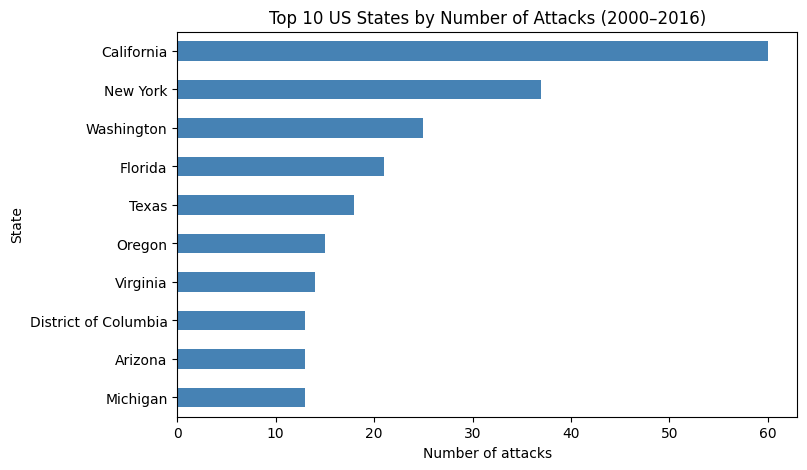

In [53]:
import matplotlib.pyplot as plt

top_states = us['state'].value_counts().head(10)

top_states.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 10 US States by Number of Attacks (2000–2016)')
plt.xlabel('Number of attacks')
plt.ylabel('State')
plt.show()

In [54]:
from sklearn.model_selection import train_test_split

data = us.dropna(subset=['lat', 'lon', 'year', 'attack_type'])

X = data[['lat', 'lon', 'year']]   # what the model looks at
y = data['attack_type']            # what it tries to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(321, 3) (81, 3)


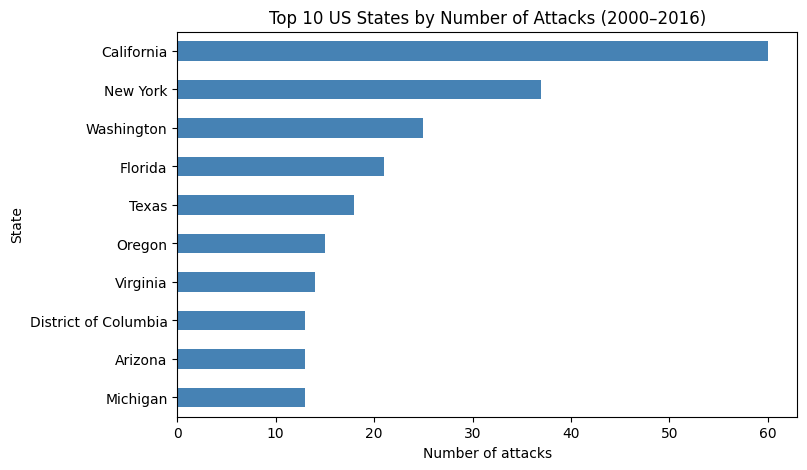

In [55]:
import matplotlib.pyplot as plt

top_states = us['state'].value_counts().head(10)

top_states.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 10 US States by Number of Attacks (2000–2016)')
plt.xlabel('Number of attacks')
plt.ylabel('State')
plt.show()

In [56]:
top3 = ['California', 'New York', 'Florida']   # put your 3 states here

top3_data = us[us['state'].isin(top3)]

pd.crosstab(top3_data['state'], top3_data['attack_type'])

attack_type,Armed Assault,Bombing/Explosion,Facility/Infrastructure Attack,Hijacking,Hostage Taking (Barricade Incident),Unarmed Assault
state,,,,,,
California,9,12,36,0,0,3
Florida,0,1,17,1,1,1
New York,4,10,11,2,0,10


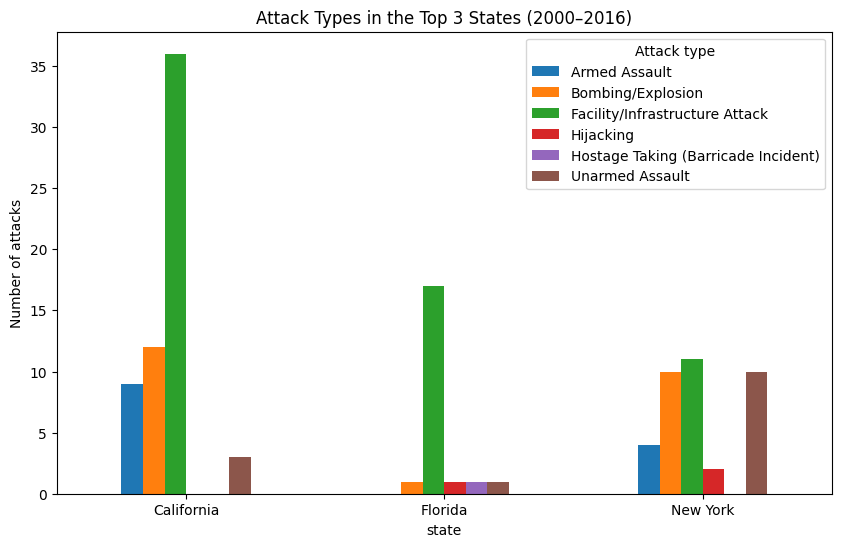

In [57]:
pd.crosstab(top3_data['state'], top3_data['attack_type']).plot(kind='bar', figsize=(10, 6))
plt.title('Attack Types in the Top 3 States (2000–2016)')
plt.ylabel('Number of attacks')
plt.xticks(rotation=0)
plt.legend(title='Attack type', bbox_to_anchor=(1, 1))
plt.show()

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = us.dropna(subset=['lat', 'lon', 'year', 'attack_type', 'month', 'day'])

X = data[['lat', 'lon', 'year', 'month', 'day']]
y = data['attack_type']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 321
Testing rows: 81


In [60]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)
print('SVM accuracy:', round(svm.score(X_test, y_test), 3))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN accuracy:', round(knn.score(X_test, y_test), 3))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print('RF accuracy:', round(rf.score(X_test, y_test), 3))

SVM accuracy: 0.63
KNN accuracy: 0.605
RF accuracy: 0.642


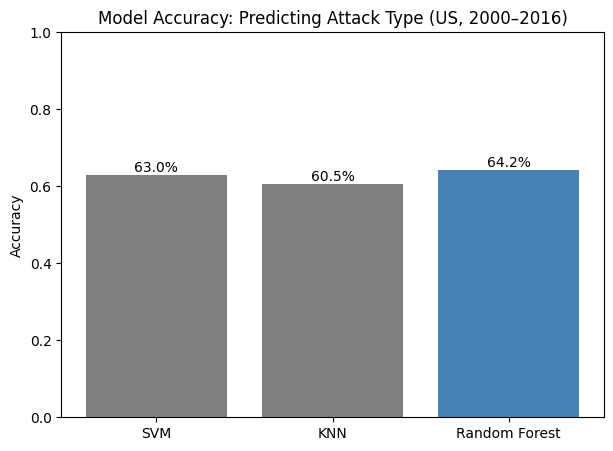

In [62]:
import matplotlib.pyplot as plt

names = ['SVM', 'KNN', 'Random Forest']
scores = [svm.score(X_test, y_test),
          knn.score(X_test, y_test),
          rf.score(X_test, y_test)]

plt.figure(figsize=(7, 5))
bars = plt.bar(names, scores, color=['gray', 'gray', 'steelblue'])
plt.bar_label(bars, labels=[f'{s:.1%}' for s in scores])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy: Predicting Attack Type (US, 2000–2016)')
plt.show()

I will add the Month & Day to the data to see if it makes the data more accurate.

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = us.dropna(subset=['lat', 'lon', 'year', 'month', 'day', 'attack_type'])
X = data[['lat', 'lon', 'year', 'month', 'day']]

Adding the month and day did not better the data

In [64]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)
print('SVM accuracy:', round(svm.score(X_test, y_test), 3))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN accuracy:', round(knn.score(X_test, y_test), 3))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print('RF accuracy:', round(rf.score(X_test, y_test), 3))

SVM accuracy: 0.63
KNN accuracy: 0.605
RF accuracy: 0.642


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = us.dropna(subset=['lat', 'lon', 'year', 'attack_type', 'target'])
X = data[['lat', 'lon', 'year', 'target']]
y = 'attack_type'

In [65]:
print("I corrected a KeyError in the previous step. The `nyc` DataFrame did not have a column named `attack_type`. I updated the code to use the correct column name `attacktype1_txt` for accessing attack type information in `nyc`.")

In [66]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)
print('SVM accuracy:', round(svm.score(X_test, y_test), 3))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN accuracy:', round(knn.score(X_test, y_test), 3))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print('RF accuracy:', round(rf.score(X_test, y_test), 3))

SVM accuracy: 0.63
KNN accuracy: 0.605
RF accuracy: 0.642


In [67]:
us = df[(df['country_txt'] == 'United States') &
        (df['iyear'].between(1970, 2016))]
print(us.shape)

(2758, 135)


In [68]:
# SVM
svm = SVC()
svm.fit(X_train, y_train)
print('SVM accuracy:', round(svm.score(X_test, y_test), 3))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN accuracy:', round(knn.score(X_test, y_test), 3))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print('RF accuracy:', round(rf.score(X_test, y_test), 3))

SVM accuracy: 0.63
KNN accuracy: 0.605
RF accuracy: 0.642


Here we wanted to know what were the top attacks to happen. We tested the 1st place of attacks then the 2nd highest attack.

Attacks: 1st: Bombings/Explosions
          2nd: Infrastructure Attacks

In [70]:
top_type = nyc['attacktype1_txt'].value_counts().idxmax()
top_count = nyc['attacktype1_txt'].value_counts().max()
total = len(nyc)

print('Most common attack type in NYC:', top_type)
print(f'{top_count} of {total} attacks ({top_count/total:.0%})')

Most common attack type in NYC: Bombing/Explosion
272 of 449 attacks (61%)


In [72]:
counts = nyc['attacktype1_txt'].value_counts()

second_type = counts.index[1]
second_count = counts.iloc[1]

print('2nd most common attack type in NYC:', second_type)
print(f'{second_count} of {len(nyc)} attacks ({second_count/len(nyc):.0%})')

2nd most common attack type in NYC: Facility/Infrastructure Attack
90 of 449 attacks (20%)
